# The tripolar north fold: do `diff` and `interp` work across the seam?

Tripolar ocean grids (MOM6, NEMO, Oceananigans) fold the northern edge of the
domain onto itself. If xgcm handles the fold correctly, fields built with
`interp` and `diff` should be **smooth across the seam**, differing from the
naive (no-fold) calculation **only along the fold row**.

We test this for **three models** (real surface velocities `u`,`v`) with two
diagnostics, each crossing the fold through a different operation:

* **surface current speed** $\sqrt{u^2+v^2}$ from `interp` — shown both
  interpolated to **tracer (centre) points** (the `v`→centre step crosses the
  fold) and to **cell corners / vorticity points** (the `u`→corner step crosses
  it), so *both* velocity components are exercised across the seam;
* the **Rossby number** $\mathrm{Ro}=\zeta/f$ from `diff`, where
  $\zeta=\partial v/\partial x-\partial u/\partial y$ (derivatives divided by the
  cell spacings) and $f=2\Omega\sin\phi$.

Each diagnostic is a **3×3 grid**: columns are the models, rows are **naive**
(no fold), **fold-aware**, and their **difference**. MOM6/NEMO use a `"corner"`
fold pivot, Oceananigans a `"u"` pivot.

> **Dependencies** — the MOM6/NEMO sections read CMIP6 from the Pangeo cloud
> (`pip install zarr gcsfs`); plots use `cartopy`.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import LogNorm

from xgcm import Grid

so = {"storage_options": {"token": "anon"}}
EARTH_RADIUS = 6371e3
OMEGA = 7.2921e-5

## Helpers

`package` puts a model's `u`,`v` on a common staggered index grid and masks land
(cells whose velocity is missing, or zero where zeros dominate — e.g. the
Oceananigans immersed boundary), so land never leaks through `interp`/`diff`.

In [2]:
def package(uo, vo, lon, lat, fold, label):
    '''Bundle surface velocities on a common staggered index grid, masking land.'''
    a = lambda x: np.asarray(getattr(x, "values", x), dtype=float)
    uo, vo, lon, lat = a(uo), a(vo), a(lon), a(lat)
    # land = missing, or (where zeros dominate, e.g. immersed boundaries) zero
    def mask_land(z):
        zz = np.where(np.isfinite(z), z, np.nan)
        if np.mean(z == 0) > 0.05:
            zz = np.where(z == 0, np.nan, zz)
        return zz
    uo, vo = mask_land(uo), mask_land(vo)
    ny, nx = uo.shape
    coords = dict(x_c=np.arange(nx), x_f=np.arange(nx), y_c=np.arange(ny), y_f=np.arange(ny))
    u = xr.DataArray(uo, dims=["y_c", "x_f"]).assign_coords(x_f=coords["x_f"], y_c=coords["y_c"])
    v = xr.DataArray(vo, dims=["y_f", "x_c"]).assign_coords(x_c=coords["x_c"], y_f=coords["y_f"])
    return dict(coords=coords, u=u, v=v, lon=lon, lat=lat, fold=fold, label=label)


def _haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, (lon1, lat1, lon2, lat2))
    h = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * EARTH_RADIUS * np.arcsin(np.sqrt(h))


def cell_spacings(lon, lat):
    lonE = np.concatenate([lon, lon[:, :1]], axis=1)
    latE = np.concatenate([lat, lat[:, :1]], axis=1)
    dx = _haversine(lonE[:, :-1], latE[:, :-1], lonE[:, 1:], latE[:, 1:])
    dy = np.empty_like(lat)
    dy[:-1] = _haversine(lon[:-1], lat[:-1], lon[1:], lat[1:])
    dy[-1] = dy[-2]
    return xr.DataArray(dx, dims=["y_f", "x_f"]), xr.DataArray(dy, dims=["y_f", "x_f"])


def _grid(coords, edge, ybc):
    return Grid(xr.Dataset(coords=coords),
                coords={"X": {"center": "x_c", edge: "x_f"},
                        "Y": {"center": "y_c", edge: "y_f"}},
                boundary={"X": "periodic", "Y": ybc}, autoparse_metadata=False)


def speed_centre(m, fold):
    '''sqrt(u^2+v^2) at tracer points; the v->centre interp crosses the fold.'''
    g = _grid(m["coords"], "left", {"fold": m["fold"]} if fold else "extend")
    uc = g.interp(m["u"], "X")
    vc = (g.interp({"Y": m["v"]}, "Y", other_component={"X": m["u"]}, boundary="extend")
          if fold else g.interp(m["v"], "Y", boundary="extend"))
    return np.hypot(uc, vc)


def speed_corner(m, fold):
    '''sqrt(u^2+v^2) at cell corners; the u->corner interp crosses the fold.'''
    g = _grid(m["coords"], "right", {"fold": m["fold"]} if fold else "extend")
    vc = g.interp(m["v"], "X")
    uc = (g.interp({"X": m["u"]}, "Y", other_component={"Y": m["v"]}, boundary="extend")
          if fold else g.interp(m["u"], "Y", boundary="extend"))
    return np.hypot(uc, vc)


def rossby(m, fold):
    '''Ro = (dv/dx - du/dy)/f at the cell corner; the du/dy diff crosses the fold.'''
    g = _grid(m["coords"], "right", {"fold": m["fold"]} if fold else "extend")
    dx, dy = cell_spacings(m["lon"], m["lat"])
    dvdx = g.diff(m["v"], "X", boundary="fill") / dx
    dudy = (g.diff({"X": m["u"]}, "Y", other_component={"Y": m["v"]}, boundary="fill")
            if fold else g.diff(m["u"], "Y", boundary="extend")) / dy
    f = xr.DataArray(2 * OMEGA * np.sin(np.radians(m["lat"])), dims=["y_f", "x_f"])
    return (dvdx - dudy) / f


def _wrap_mask(lon):
    '''True for cells whose longitude jumps (the fold seam / dateline) -- these
    become huge wrapping quads in pcolormesh and must be dropped.'''
    dxl = np.abs((np.diff(lon, axis=1, append=lon[:, :1]) + 180) % 360 - 180)
    dyl = np.abs((np.diff(lon, axis=0, append=lon[-1:, :]) + 180) % 360 - 180)
    return (dxl > 90) | (dyl > 90)


def grid3x3(fn, models, *, title, cmap, label, norm=None, diff_cmap="RdBu_r", vlim=None):
    '''Plot fn(m, fold) for fold in {naive, fold} and their difference, as a
    3x3 grid (columns = models; rows = naive / fold / naive-minus-fold).'''
    naive = [fn(m, False) for m in models]
    fold = [fn(m, True) for m in models]
    diff = [a - b for a, b in zip(naive, fold)]

    def sym(fields, pct=99, nonzero=False):
        # symmetric limit per field, then take the median across models so one
        # eddy-rich model doesn't wash the others out
        lims = []
        for f in fields:
            v = np.abs(np.asarray(f.values).ravel())
            v = v[np.isfinite(v)]
            if nonzero:
                v = v[v > 0]
            lims.append(float(np.nanpercentile(v, pct)) if v.size else 1.0)
        return float(np.median(lims))

    if norm is not None:
        main = None
    elif vlim is not None:
        main = vlim
    else:
        main = sym(fold, pct=96)
    dlim = sym(diff, pct=99, nonzero=True)
    rows = [("naive (no fold)", naive), ("fold", fold), ("naive − fold", diff)]
    fig, axes = plt.subplots(3, 3, figsize=(15, 14),
                             subplot_kw=dict(projection=ccrs.NorthPolarStereo()))
    cmap_m = plt.get_cmap(cmap).copy(); cmap_m.set_bad("lightgray")     # land -> grey
    cmap_d = plt.get_cmap(diff_cmap).copy(); cmap_d.set_bad("lightgray")
    for r, (rlabel, row) in enumerate(rows):
        is_diff = (r == 2)
        for c, m in enumerate(models):
            ax = axes[r, c]
            ax.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
            ax.set_facecolor("lightgray")
            kw = dict(transform=ccrs.PlateCarree(), shading="nearest")
            if is_diff:
                kw.update(cmap=cmap_d, vmin=-dlim, vmax=dlim)
            elif norm is not None:
                kw.update(cmap=cmap_m, norm=norm)
            else:
                kw.update(cmap=cmap_m, vmin=-main, vmax=main)
            arr = np.asarray(row[c].values)
            bad = ~np.isfinite(arr) | _wrap_mask(m["lon"])
            pm = ax.pcolormesh(m["lon"], m["lat"], np.ma.masked_where(bad, arr), **kw)
            ax.coastlines(linewidth=0.3, color="0.5")
            ax.gridlines(color="k", alpha=0.15, linewidth=0.2)
            if r == 0:
                ax.set_title(m["label"], fontsize=10)
            if c == 0:
                ax.text(-0.12, 0.5, rlabel, transform=ax.transAxes, rotation=90,
                        va="center", ha="center", fontsize=11, fontweight="bold")
        clabel = label if not is_diff else "Δ " + label
        fig.colorbar(pm, ax=list(axes[r, :]), shrink=0.7, pad=0.02, label=clabel)
    fig.suptitle(title, fontsize=14, y=0.93)
    plt.show()

## Load the three models

CMIP6 surface velocities for MOM6 (GFDL-CM4) and NEMO (IPSL-CM6A-LR) from the
Pangeo cloud, plus a realistic 1° ClimaOcean/Oceananigans surface snapshot.
CMIP6 masks its redundant northern row, so we drop it before folding.

In [3]:
def _cmip6_surface(source_id, version, fold, label):
    inst = {"GFDL-CM4": "NOAA-GFDL", "IPSL-CM6A-LR": "IPSL"}[source_id]
    base = (f"gs://cmip6/CMIP6/CMIP/{inst}/{source_id}/historical/"
            f"r1i1p1f1/Omon/{{var}}/gn/{version}/")

    def s(var):
        d = xr.open_dataset(base.format(var=var), engine="zarr", backend_kwargs=so)
        return d[var].isel(time=0).isel({d[var].dims[1]: 0})

    uo = s("uo").isel(y=slice(0, -1))
    vo = s("vo").isel(y=slice(0, -1))
    g = xr.open_dataset(base.format(var="uo"), engine="zarr", backend_kwargs=so)
    lonn = "lon" if "lon" in g.variables else "nav_lon"
    latn = "lat" if "lat" in g.variables else "nav_lat"
    return package(uo, vo, g[lonn].isel(y=slice(0, -1)).values,
                   g[latn].isel(y=slice(0, -1)).values, fold, label)


def _oceananigans():
    o = xr.open_dataset("oceananigans_tripolar.nc")
    return package(o["u"].transpose("y_c", "x_f"), o["v"].transpose("y_f", "x_c"),
                   o["lon_cc"].transpose("y_c", "x_c"), o["lat_cc"].transpose("y_c", "x_c"),
                   "u", "Oceananigans (ClimaOcean 1°)")


models = [
    _cmip6_surface("GFDL-CM4", "v20180701", "corner", "MOM6 (GFDL-CM4)"),
    _cmip6_surface("IPSL-CM6A-LR", "v20180803", "corner", "NEMO (IPSL-CM6A-LR)"),
    _oceananigans(),
]

## `interp` across the fold — surface speed at tracer (centre) points

The `v`→centre interpolation crosses the seam. Naive and fold-aware rows are
indistinguishable; the difference is confined to the fold row.

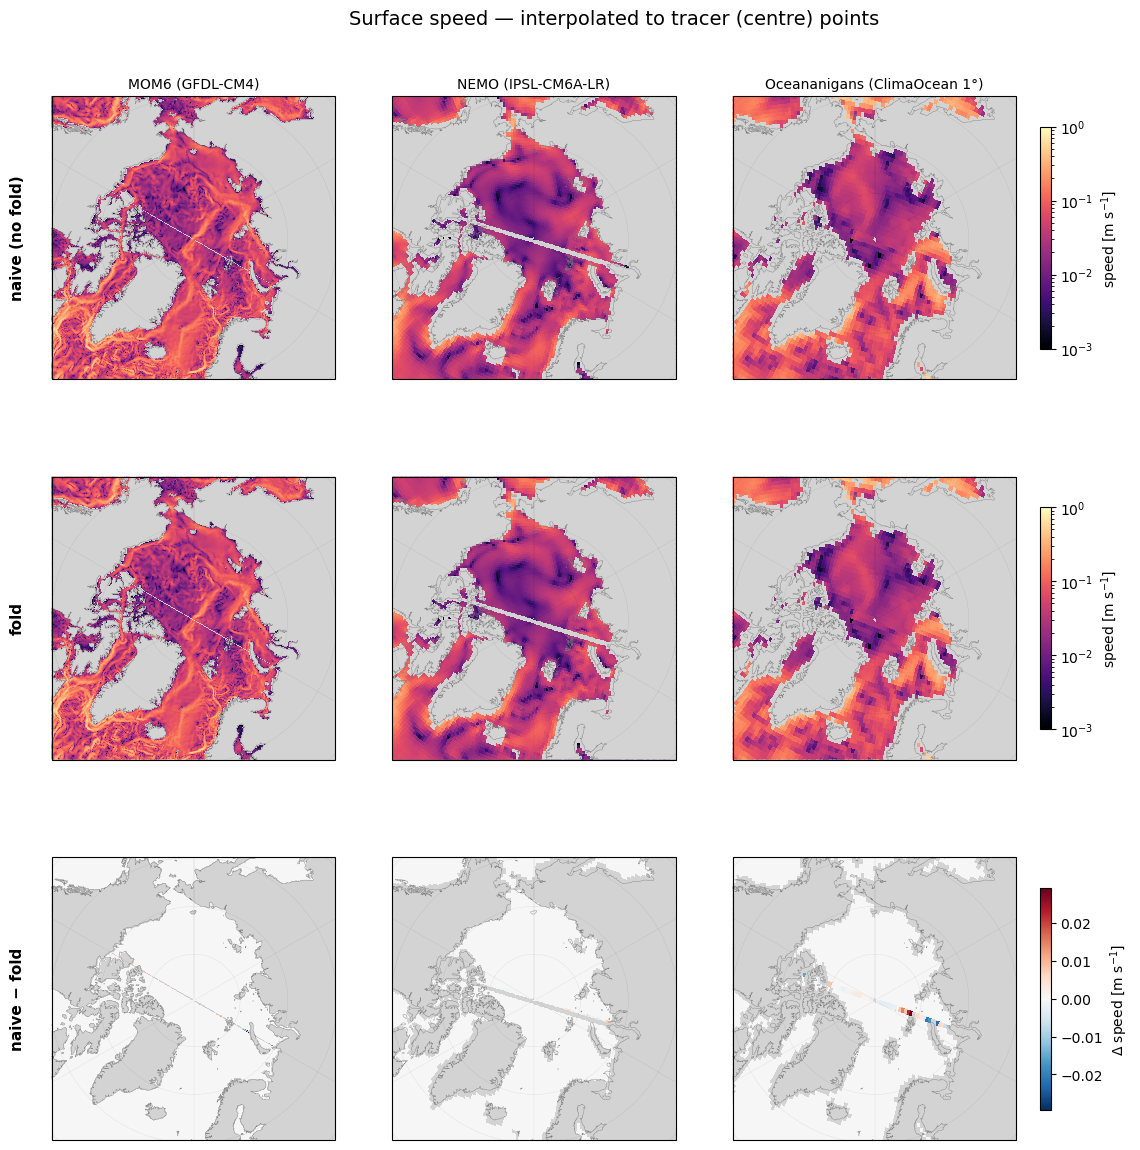

In [4]:
grid3x3(speed_centre, models, title="Surface speed — interpolated to tracer (centre) points",
        cmap="magma", norm=LogNorm(vmin=1e-3, vmax=1.0), label="speed [m s$^{-1}$]")

## `interp` across the fold — surface speed at corners (vorticity points)

Here the `u`→corner interpolation crosses the seam instead — the *other* velocity
component. Again smooth across the fold, differing only on the fold row.

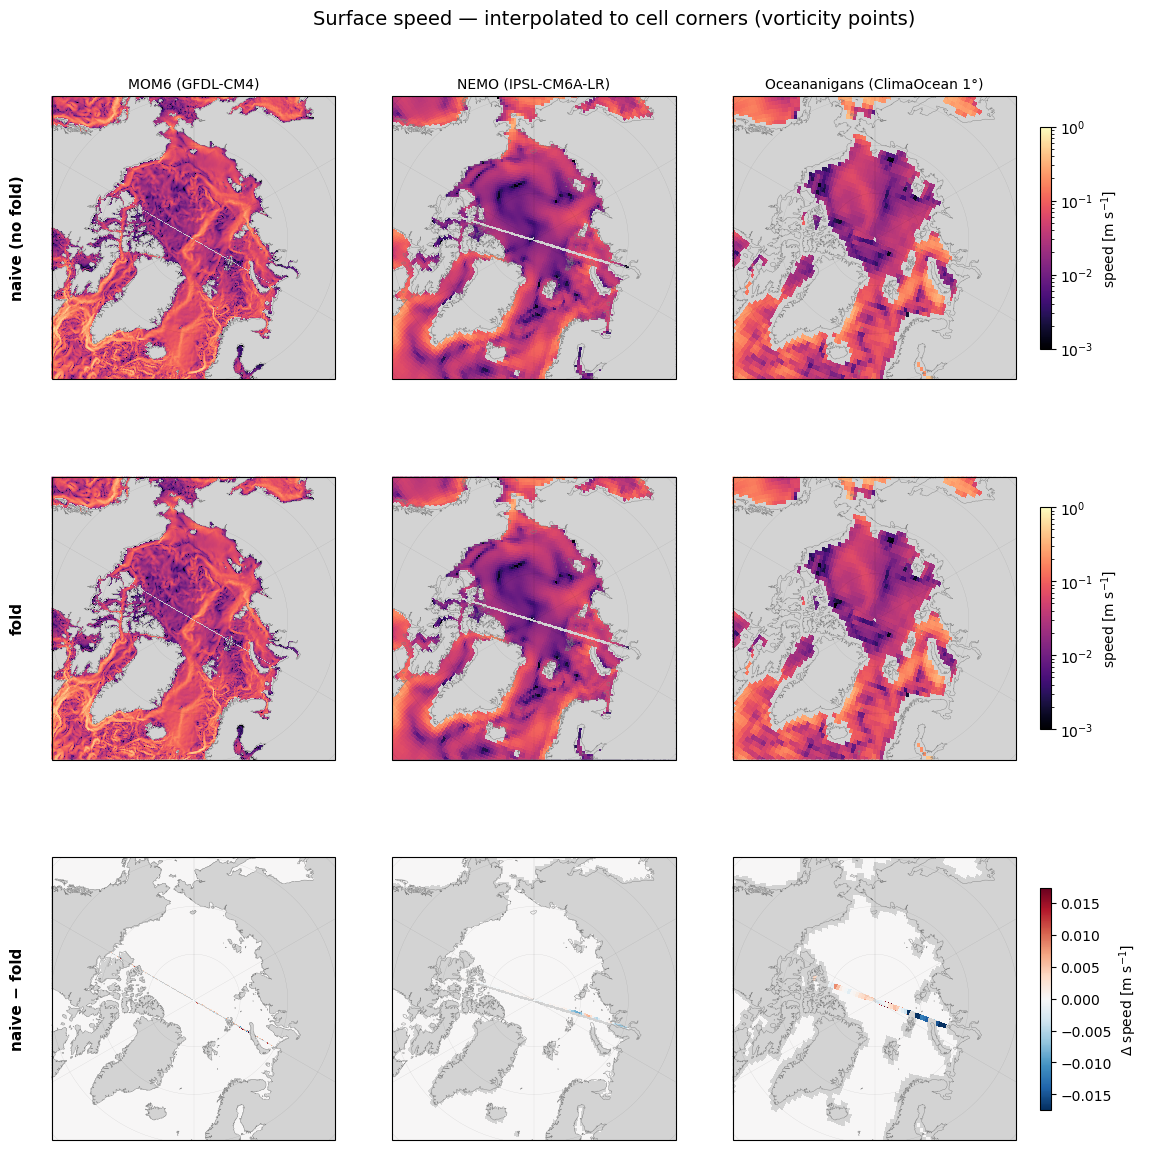

In [5]:
grid3x3(speed_corner, models, title="Surface speed — interpolated to cell corners (vorticity points)",
        cmap="magma", norm=LogNorm(vmin=1e-3, vmax=1.0), label="speed [m s$^{-1}$]")

## `diff` across the fold — Rossby number $\zeta/f$

The $\partial u/\partial y$ difference crosses the seam. The fold-aware Rossby
number is smooth across the pole; the naive one is not.

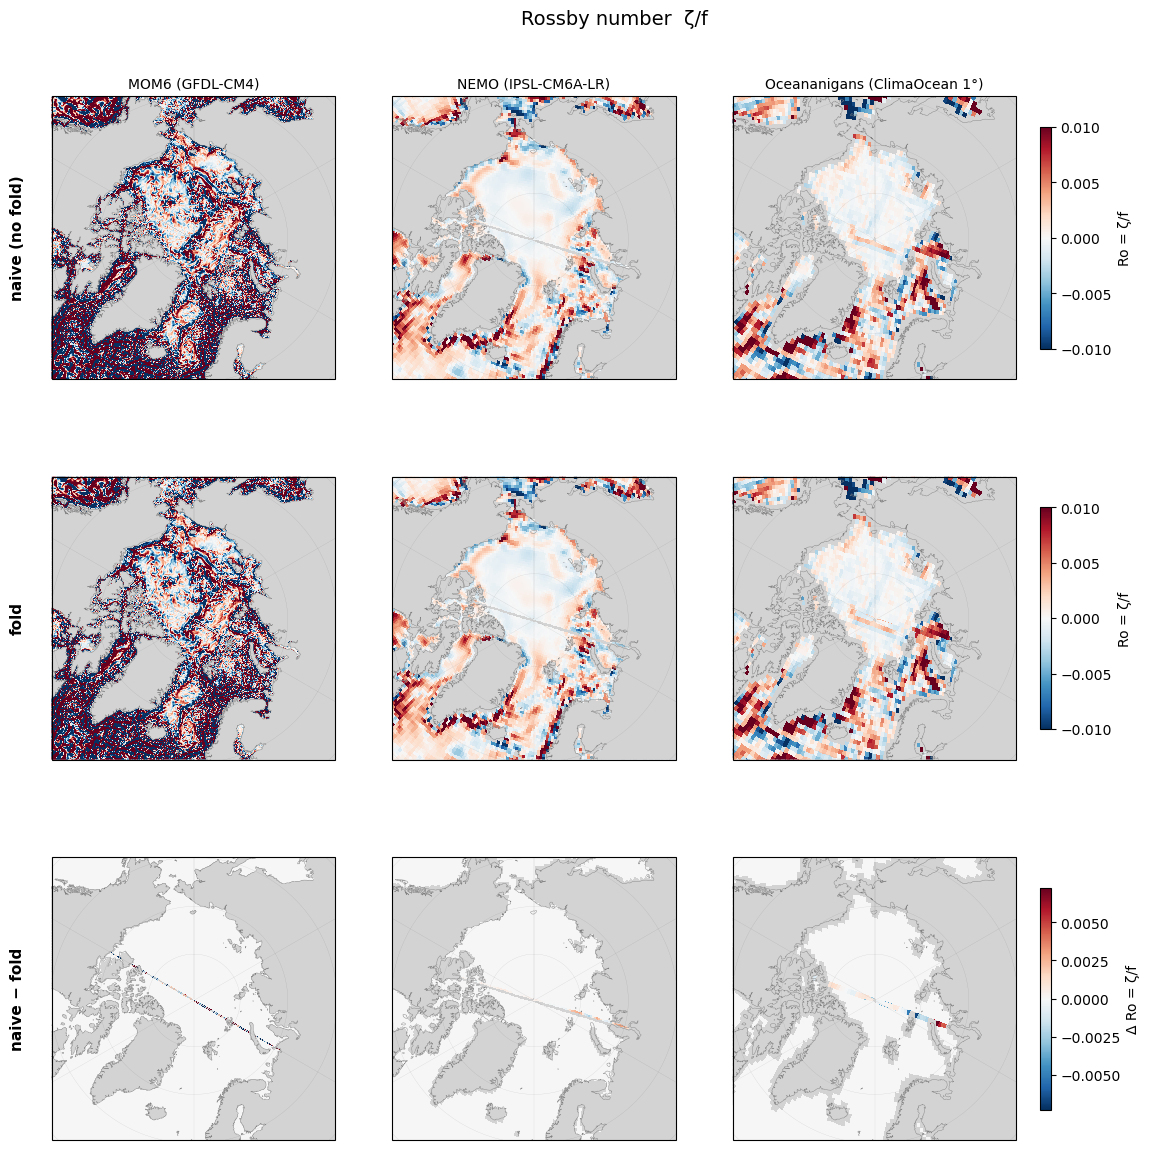

In [6]:
grid3x3(rossby, models, title="Rossby number  ζ/f", cmap="RdBu_r", label="Ro = ζ/f", vlim=0.01)

## Takeaway

For all three tripolar conventions (MOM6/NEMO `"corner"`, Oceananigans `"u"`),
**both** velocity components are interpolated and differenced correctly across
the North fold: surface speed (to centres *and* to corners) and the Rossby
number are smooth across the seam, and differ from the naive no-fold calculation
**only on the single fold row**. xgcm's `boundary={"Y": {"fold": ...}}` mirrors
the seam and sign-flips folded velocities so the standard staggered operators
work across the pole. (xgcm's reconstructed fold halos were verified to match
Oceananigans' own zipper exactly for the tracer and both velocity components.)

The faint band of vorticity right at the fold in the low-resolution Oceananigans
panel is *not* an artifact of the fold operators — it appears identically in the
naive and fold-aware columns because it lives in the model's **velocity field**:
a grid-scale "north-fold noise" (a step in the across-fold direction, smooth
along the seam) of the kind tripolar models develop near the seam, here
accentuated by the coarse 1° grid and short 10-day spin-up.

See the [grid topology](../grid_topology.md) docs and [`03_MOM6.ipynb`](03_MOM6.ipynb).